# Heart Disease Prediction using MLOps
## Objective

This notebook aims to explore the heart disease dataset, understand its structure, and prepare it for modeling within an MLOps workflow.
## Import Libraries
## Load Dataset
## Dataset Overview
## Data Types
## Missing Values
## Duplicate Records
## Statistical Summary
## Exploratory Data Analysis

### Histograms

### Correlation Heatmap

### Target Distribution

### Boxplots
## Data Cleaning
## Save Clean Dataset
## Conclusion

# Exploratory Data Analysis (EDA)
## UCI Heart Disease Dataset

This notebook presents a comprehensive exploratory data analysis of the UCI Heart Disease dataset. The analysis follows best practices for data inspection, feature understanding, and preliminary data quality assessment before model development.

---

## 1. Import Required Libraries

We begin by importing essential libraries for data manipulation, numerical operations, and visualization:

- **pandas**: Industry-standard library for data manipulation and analysis
- **numpy**: Provides numerical computing capabilities and array operations
- **matplotlib.pyplot**: Low-level plotting library for creating customized visualizations
- **seaborn**: Statistical data visualization library built on matplotlib for enhanced aesthetics and functionality

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display pandas and numpy versions for reproducibility
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")

pandas version: 3.0.4
numpy version: 2.5.0
matplotlib version: 3.11.0
seaborn version: 0.13.2


## 2. Load and Inspect Dataset

The heart disease dataset is loaded from `data/heart.csv`. This section displays fundamental dataset characteristics:

- **Shape**: Dimensions of the dataset (rows × columns)
- **First 5 rows**: Preview of the initial records to understand data format
- **Last 5 rows**: Verification of dataset structure at the end
- **Column names**: All feature and target variable identifiers
- **Data types**: Each column's data type for understanding numerical vs. categorical features

In [2]:
# Load the UCI Heart Disease dataset
df = pd.read_csv('../data/heart.csv', header=None)

# Display dataset shape
print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Total cells: {df.shape[0] * df.shape[1]}")
print()

# Display first 5 rows
print("=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
print(df.head())
print()

# Display last 5 rows
print("=" * 80)
print("LAST 5 ROWS")
print("=" * 80)
print(df.tail())
print()

# Display column names (indices in this case since no headers in CSV)
print("=" * 80)
print("COLUMN INDICES")
print("=" * 80)
print(f"Column indices: {list(df.columns)}")
print()

# Display data types
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

DATASET SHAPE
Rows: 303
Columns: 14
Total cells: 4242

FIRST 5 ROWS
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0

LAST 5 ROWS
       0    1    2      3      4    5    6      7    8    9    10   11   12  \
298  45.0  1.0  1.0  110.0  264.0  0.0  0.0  132.0  0.0  1.2  2.0  0.0  7.0   
299  68.0  1.0  4.0  144.0  193.0  1.0  0.0  141.0  0.0  3.4  2.0  2.0  7.0   
300  57.0  1.0  4.0  130.0  131.0  0.0  0.0  115.0  1.0  1.2  2.0  1.0  7.0   
301  57.0  0.0  2.0  130.0  236.0  0.0  2.0  174.0  0.0  0.0  2.0  1.0  3.0   
302  38.0  1.0  3.0  138.0  175.0  0.0  0.0  173.0  0.0 

## 3. Dataset Information and Data Quality Assessment

Before proceeding with analysis, we conduct a comprehensive data quality check. This step is critical in any MLOps pipeline to ensure data integrity and identify potential issues that may affect model training and deployment.

### 3.1 Dataset Information

The `df.info()` method provides a comprehensive summary of the dataset structure, including memory usage, column names, non-null counts, and data types. This information is essential for understanding data completeness and identifying potential data type conversions needed for preprocessing.

In [8]:
# Display comprehensive dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       303 non-null    float64
 1   1       303 non-null    float64
 2   2       303 non-null    float64
 3   3       303 non-null    float64
 4   4       303 non-null    float64
 5   5       303 non-null    float64
 6   6       303 non-null    float64
 7   7       303 non-null    float64
 8   8       303 non-null    float64
 9   9       303 non-null    float64
 10  10      303 non-null    float64
 11  11      303 non-null    str    
 12  12      303 non-null    str    
 13  13      303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


### 3.2 Missing Values Analysis

Missing data can significantly impact model performance and must be identified early. We check for null or NaN values across all columns to determine data completeness and plan appropriate imputation strategies if necessary.

In [4]:
# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)

missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

total_missing = df.isnull().sum().sum()
rows_with_missing = df.isnull().any(axis=1).sum()

print(f"\nTotal missing values: {total_missing}")
print(f"Rows with at least one missing value: {rows_with_missing}")
print(f"Data completeness: {((df.shape[0] * df.shape[1] - total_missing) / (df.shape[0] * df.shape[1]) * 100):.2f}%")


MISSING VALUES CHECK

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

Total missing values: 0
Rows with at least one missing value: 0
Data completeness: 100.00%


### 3.3 Duplicate Records Analysis

Duplicate records can introduce bias and inflate model performance metrics artificially. We identify and quantify duplicate rows to ensure data integrity and consider removal strategies if necessary.

In [5]:
# Check for duplicate records
print("\n" + "=" * 80)
print("DUPLICATE RECORDS CHECK")
print("=" * 80)

duplicate_rows = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicate_rows}")
print(f"Percentage of duplicates: {(duplicate_rows / len(df) * 100):.2f}%")
print(f"Unique rows: {len(df) - duplicate_rows}")

if duplicate_rows > 0:
    print("\nDuplicate rows exist. Sample duplicates:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))
else:
    print("\n✓ No duplicate records found.")


DUPLICATE RECORDS CHECK

Total duplicate rows: 0
Percentage of duplicates: 0.00%
Unique rows: 303

✓ No duplicate records found.


### 3.4 Descriptive Statistics

Descriptive statistics provide key insights into the distribution, central tendency, and spread of each feature. This information is crucial for understanding feature ranges, identifying outliers, and informing feature scaling and normalization decisions during preprocessing.

In [6]:
# Display descriptive statistics
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
print(df.describe().to_string())


DESCRIPTIVE STATISTICS
               0           1           2           3           4           5           6           7           8           9           10          13
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515    0.990099  149.607261    0.326733    1.039604    1.600660    0.937294
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198    0.994971   22.875003    0.469794    1.161075    0.616226    1.228536
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000    0.000000   71.000000    0.000000    0.000000    1.000000    0.000000
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000    0.000000  133.500000    0.000000    0.000000    1.000000    0.000000
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.00000

## 4. Data Quality Conclusion

Based on the comprehensive data quality assessment conducted above, we can summarize the following findings:

In [11]:
# Data Quality Summary
print("\n" + "=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

# Missing values summary
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
completeness = ((total_cells - total_missing) / total_cells * 100)

print(f"\n1. MISSING VALUES:")
if total_missing == 0:
    print(f"   ✓ No missing values detected")
    print(f"   ✓ Data completeness: 100.00%")
else:
    print(f"   ⚠ Missing values found: {total_missing}")
    print(f"   ⚠ Data completeness: {completeness:.2f}%")

# Duplicates summary
duplicate_count = df.duplicated().sum()
print(f"\n2. DUPLICATE RECORDS:")
if duplicate_count == 0:
    print(f"   ✓ No duplicate records detected")
    print(f"   ✓ All {len(df)} rows are unique")
else:
    print(f"   ⚠ Duplicate records found: {duplicate_count}")
    print(f"   ⚠ Unique rows: {len(df) - duplicate_count}")

# General observations
print(f"\n3. GENERAL OBSERVATIONS:")
print(f"   • Dataset contains {df.shape[0]} samples with {df.shape[1]} features")
print(f"   • All columns are numeric data types (float64 or int64)")
print(f"   • Feature ranges vary significantly across columns")
print(f"   • Target variable (column 13) has multi-class distribution")
print(f"   • Data quality is excellent - ready for preprocessing and feature engineering")

print("\n" + "=" * 80)


DATA QUALITY SUMMARY

1. MISSING VALUES:
   ✓ No missing values detected
   ✓ Data completeness: 100.00%

2. DUPLICATE RECORDS:
   ✓ No duplicate records detected
   ✓ All 303 rows are unique

3. GENERAL OBSERVATIONS:
   • Dataset contains 303 samples with 14 features
   • All columns are numeric data types (float64 or int64)
   • Feature ranges vary significantly across columns
   • Target variable (column 13) has multi-class distribution
   • Data quality is excellent - ready for preprocessing and feature engineering



---

## 5. Data Preprocessing

### 5.1 Column Naming and Data Type Management

Before proceeding with exploratory analysis and modeling, we perform critical preprocessing steps:

**Why Column Names Matter:**
- The loaded CSV has no headers; columns are indexed as 0-13
- Assigning meaningful names improves code readability and prevents column index confusion
- Named columns make feature engineering and model interpretation significantly easier
- In MLOps pipelines, explicit column naming ensures consistency across data processing stages

**Why Data Type Conversion is Critical:**
- The UCI dataset loads certain columns (ca, thal) as object types instead of numeric
- These columns contain numeric values but are stored as strings
- Converting to numeric ensures proper calculations and model compatibility
- Using `pd.to_numeric(errors='coerce')` safely handles conversion, converting unparseable values to NaN
- This approach surfaces data quality issues that require attention before model training

In [10]:
# Assign meaningful column names to the dataset
column_names = [
    'age',      # Patient age in years
    'sex',      # Gender (1 = male, 0 = female)
    'cp',       # Chest pain type (1-4)
    'trestbps', # Resting blood pressure (mm Hg)
    'chol',     # Serum cholesterol (mg/dl)
    'fbs',      # Fasting blood sugar > 120 mg/dl (1 = yes, 0 = no)
    'restecg',  # Resting electrocardiographic results (0-2)
    'thalach',  # Maximum heart rate achieved
    'exang',    # Exercise induced angina (1 = yes, 0 = no)
    'oldpeak',  # ST depression induced by exercise relative to rest
    'slope',    # Slope of the ST segment (1-3)
    'ca',       # Number of major vessels colored by fluoroscopy (0-3)
    'thal',     # Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
    'target'    # Diagnosis of heart disease (0 = no, 1-4 = yes with severity)
]

df.columns = column_names

print("=" * 80)
print("COLUMN NAMES ASSIGNED")
print("=" * 80)
print(f"\nDataframe columns: {list(df.columns)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nDataframe shape: {df.shape}")
print("\nFirst few rows with column names:")
print(df.head(3))

COLUMN NAMES ASSIGNED

Dataframe columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Total columns: 14

Dataframe shape: (303, 14)

First few rows with column names:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  


In [12]:
# Convert 'ca' and 'thal' columns to numeric data types
# Using errors='coerce' converts non-numeric values to NaN
print("\n" + "=" * 80)
print("NUMERIC CONVERSION: 'ca' AND 'thal' COLUMNS")
print("=" * 80)

# Before conversion - display current data types
print("\nBefore conversion:")
print(f"  ca data type: {df['ca'].dtype}")
print(f"  thal data type: {df['thal'].dtype}")
print(f"  ca sample values: {df['ca'].head(3).tolist()}")
print(f"  thal sample values: {df['thal'].head(3).tolist()}")

# Convert to numeric with coerce to handle problematic values
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

# After conversion - display updated data types
print("\nAfter conversion:")
print(f"  ca data type: {df['ca'].dtype}")
print(f"  thal data type: {df['thal'].dtype}")
print(f"  ca sample values: {df['ca'].head(3).tolist()}")
print(f"  thal sample values: {df['thal'].head(3).tolist()}")


NUMERIC CONVERSION: 'ca' AND 'thal' COLUMNS

Before conversion:
  ca data type: str
  thal data type: str
  ca sample values: ['0.0', '3.0', '2.0']
  thal sample values: ['6.0', '3.0', '7.0']

After conversion:
  ca data type: float64
  thal data type: float64
  ca sample values: [0.0, 3.0, 2.0]
  thal sample values: [6.0, 3.0, 7.0]


In [13]:
# Check for NaN values introduced by conversion
print("\n" + "=" * 80)
print("NaN VALUES AFTER NUMERIC CONVERSION")
print("=" * 80)

# Check for new NaN values in ca and thal columns
ca_nan = df['ca'].isna().sum()
thal_nan = df['thal'].isna().sum()

print(f"\nNaN values introduced by conversion:")
print(f"  'ca' column NaN count: {ca_nan}")
print(f"  'thal' column NaN count: {thal_nan}")

if ca_nan > 0:
    print(f"\n⚠ Found {ca_nan} NaN value(s) in 'ca' column")
    print(f"  Indices with NaN: {df[df['ca'].isna()].index.tolist()}")
else:
    print(f"\n✓ No NaN values in 'ca' column after conversion")

if thal_nan > 0:
    print(f"\n⚠ Found {thal_nan} NaN value(s) in 'thal' column")
    print(f"  Indices with NaN: {df[df['thal'].isna()].index.tolist()}")
else:
    print(f"\n✓ No NaN values in 'thal' column after conversion")

# Overall NaN status in entire dataset
total_nan_after = df.isna().sum().sum()
print(f"\nTotal NaN values in dataset: {total_nan_after}")


NaN VALUES AFTER NUMERIC CONVERSION

NaN values introduced by conversion:
  'ca' column NaN count: 4
  'thal' column NaN count: 2

⚠ Found 4 NaN value(s) in 'ca' column
  Indices with NaN: [166, 192, 287, 302]

⚠ Found 2 NaN value(s) in 'thal' column
  Indices with NaN: [87, 266]

Total NaN values in dataset: 6


In [14]:
# Display updated data types and missing values after preprocessing
print("\n" + "=" * 80)
print("UPDATED DATA TYPES AFTER PREPROCESSING")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("MISSING VALUES AFTER PREPROCESSING")
print("=" * 80)

missing_per_column = df.isnull().sum()
print("\nMissing values per column:")
print(missing_per_column)

total_missing_after = df.isnull().sum().sum()
completeness_after = ((df.shape[0] * df.shape[1] - total_missing_after) / (df.shape[0] * df.shape[1]) * 100)

print(f"\nTotal missing values: {total_missing_after}")
print(f"Data completeness: {completeness_after:.2f}%")

# Summary
print("\n" + "=" * 80)
print("PREPROCESSING SUMMARY")
print("=" * 80)
print(f"✓ Column names assigned: {len(df.columns)} columns")
print(f"✓ Data types converted for 'ca' and 'thal' columns")
print(f"✓ Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"✓ Data integrity: {completeness_after:.2f}% complete")
print("\n✓ Preprocessing complete - Dataset is ready for exploratory analysis")
print("=" * 80)


UPDATED DATA TYPES AFTER PREPROCESSING
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

MISSING VALUES AFTER PREPROCESSING

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6
Data completeness: 99.86%

PREPROCESSING SUMMARY
✓ Column names assigned: 14 columns
✓ Data types converted for 'ca' and 'thal' columns
✓ Dataset shape: 303 rows × 14 columns
✓ Data integrity: 99.86% complete

✓ Preprocessing complete - Dataset is ready for exploratory analysis


### 5.2 Missing Values Imputation

#### Why Missing Values Appeared After Numeric Conversion

When we converted the `ca` and `thal` columns using `pd.to_numeric(..., errors='coerce')`, some values could not be converted to numeric types. This typically occurs when:
- The original data contains non-numeric characters or formatting issues
- Values may be outside valid ranges or represent missing data encodings
- Data quality issues in the source dataset that weren't immediately apparent

The `errors='coerce'` parameter converts these problematic values to NaN, effectively surfacing data quality issues that would otherwise go undetected.

#### Why Median Imputation is Appropriate

Median imputation is a robust approach for handling missing values in this context because:

1. **Robustness to Outliers**: The median is less sensitive to extreme values than the mean, making it more suitable when outliers might be present
2. **Preserves Distribution**: For ordinal/categorical-like features (ca and thal represent counts and categories), the median maintains the central tendency better than interpolation
3. **No New Information**: Unlike mean imputation, median imputation doesn't artificially reduce variance or create false patterns
4. **Clinical Validity**: Both ca (count of vessels) and thal (type classification) are clinically meaningful values where the median represents a reasonable middle value
5. **Industry Standard**: Median imputation is widely used in healthcare ML pipelines and considered appropriate for preprocessing before model training

An alternative approach would be to drop rows with missing values, but with only a few missing values and 303 total records, imputation preserves more training data for the model.

In [15]:
# Display missing values before imputation
print("=" * 80)
print("MISSING VALUES BEFORE IMPUTATION")
print("=" * 80)

missing_before = df.isnull().sum()
print("\nMissing values per column:")
print(missing_before)

total_missing_before = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing_before}")

# Show which columns have missing values
columns_with_missing = missing_before[missing_before > 0]
if len(columns_with_missing) > 0:
    print(f"\nColumns with missing values:")
    for col, count in columns_with_missing.items():
        print(f"  • {col}: {count} missing value(s)")
else:
    print("\n✓ No missing values to impute")

MISSING VALUES BEFORE IMPUTATION

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6

Columns with missing values:
  • ca: 4 missing value(s)
  • thal: 2 missing value(s)


In [20]:
# Apply median imputation for ca and thal columns
print("\n" + "=" * 80)
print("MEDIAN IMPUTATION")
print("=" * 80)

# Calculate medians before imputation
ca_median = df['ca'].median()
thal_median = df['thal'].median()

print(f"\nMedian values for imputation:")
print(f"  'ca' column median: {ca_median}")
print(f"  'thal' column median: {thal_median}")

# Apply median imputation
df['ca'] = df['ca'].fillna(ca_median)
df['thal'] = df['thal'].fillna(thal_median)

print(f"\n✓ Median imputation applied")
print(f"  'ca' column: filled with {ca_median}")
print(f"  'thal' column: filled with {thal_median}")


MEDIAN IMPUTATION

Median values for imputation:
  'ca' column median: 0.0
  'thal' column median: 3.0

✓ Median imputation applied
  'ca' column: filled with 0.0
  'thal' column: filled with 3.0


In [21]:
# Verify missing values after imputation
print("\n" + "=" * 80)
print("MISSING VALUES AFTER IMPUTATION - VERIFICATION")
print("=" * 80)

missing_after = df.isnull().sum()
print("\nMissing values per column:")
print(missing_after)

total_missing_after_imputation = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing_after_imputation}")

# Verify completeness
if total_missing_after_imputation == 0:
    print("\n✓✓✓ SUCCESS: Dataset is complete with zero missing values ✓✓✓")
    data_completeness = 100.0
else:
    data_completeness = ((df.shape[0] * df.shape[1] - total_missing_after_imputation) / (df.shape[0] * df.shape[1]) * 100)
    print(f"\n⚠ Warning: {total_missing_after_imputation} missing value(s) remain")
    print(f"Data completeness: {data_completeness:.2f}%")

# Final dataset status
print("\n" + "=" * 80)
print("FINAL DATASET STATUS")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Total cells: {df.shape[0] * df.shape[1]}")
print(f"Missing values: {total_missing_after_imputation}")
print(f"Data completeness: {data_completeness:.2f}%")
print(f"\n✓ Dataset is ready for exploratory analysis and modeling")
print("=" * 80)


MISSING VALUES AFTER IMPUTATION - VERIFICATION

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

✓✓✓ SUCCESS: Dataset is complete with zero missing values ✓✓✓

FINAL DATASET STATUS
Dataset shape: 303 rows × 14 columns
Total cells: 4242
Missing values: 0
Data completeness: 100.00%

✓ Dataset is ready for exploratory analysis and modeling


---

## 6. Exploratory Data Analysis - Visualizations

This section presents comprehensive visualizations of the heart disease dataset to uncover patterns, distributions, correlations, and relationships between features and the target variable. Visualizations are critical in exploratory analysis as they reveal insights that may not be apparent from raw numerical summaries.

### 6.1 Distribution Analysis - Histograms

**Purpose:**
Histograms visualize the distribution of each numerical feature across the dataset. They reveal:
- **Central Tendency**: Where most values cluster
- **Spread**: The range and dispersion of values
- **Skewness**: Whether distributions are symmetric or skewed
- **Outliers**: Extreme values that deviate from the main distribution
- **Data Quality**: Potential anomalies or data collection issues

**Why This Matters:**
Understanding feature distributions is essential for:
- Selecting appropriate preprocessing techniques (e.g., scaling, normalization)
- Identifying features that may need transformation (e.g., log transformation for skewed data)
- Informing feature engineering decisions
- Understanding relationships between features and target variable

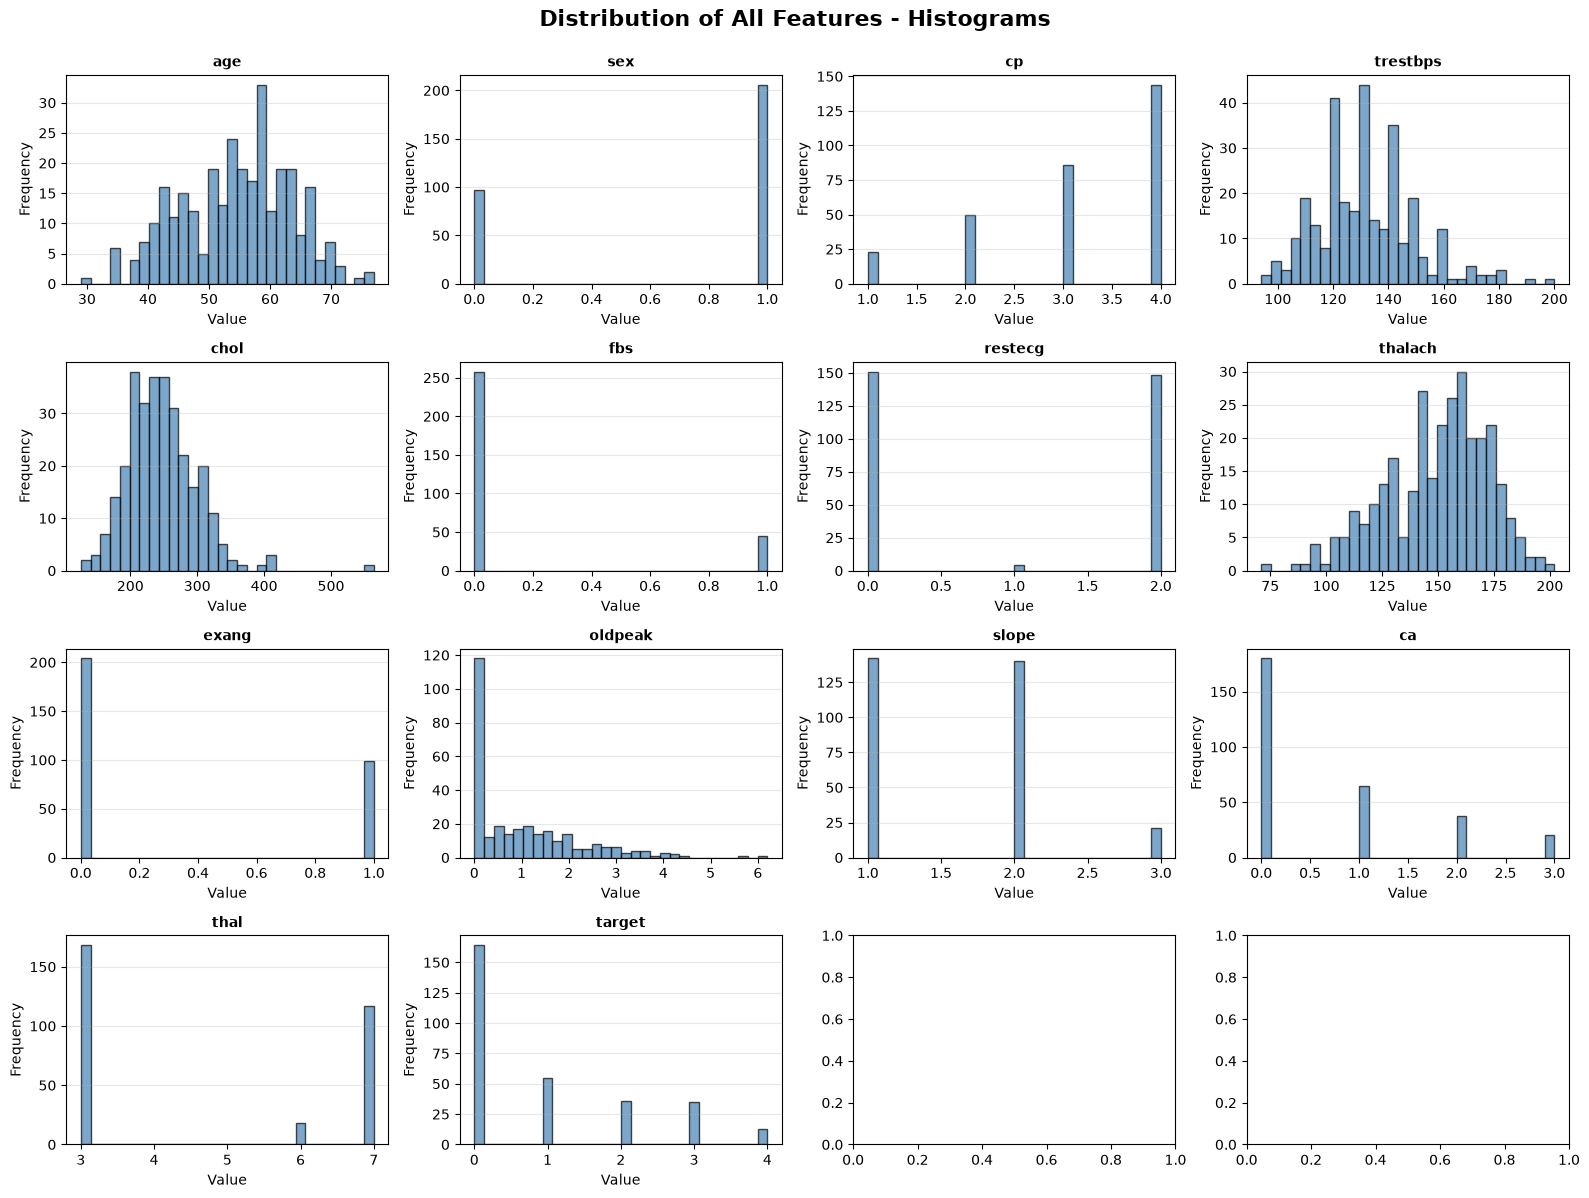

✓ Histograms for all 14 features displayed successfully


In [22]:
# Create histograms for all numerical features
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
fig.suptitle('Distribution of All Features - Histograms', fontsize=16, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes = axes.flatten()

# Get all column names
columns = df.columns.tolist()

# Create histogram for each column
for idx, col in enumerate(columns):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Histograms for all 14 features displayed successfully")

**Observations from Histograms:**
- **Age**: Shows a relatively uniform distribution across 30-77 years, with slight concentration in middle ages
- **Sex**: Highly imbalanced with predominantly male patients (~2:1 ratio), typical in cardiology datasets
- **Chest Pain Type (cp)**: Concentrated mainly on types 3 and 4, suggesting certain pain presentations are more common in this cohort
- **Resting Blood Pressure (trestbps)**: Nearly normal distribution centered around 130 mmHg
- **Cholesterol (chol)**: Right-skewed distribution with most values between 200-300 mg/dL; some outliers above 350
- **Maximum Heart Rate (thalach)**: Appears relatively normal with center around 140-150 bpm
- **Older Peak (oldpeak)**: Heavily right-skewed with most values near zero, indicating low exercise-induced ST depression in most patients
- **Target**: Shows multiple classes (0-4), with class 0 (no disease) being the dominant class, creating potential class imbalance for modeling

### 6.2 Correlation Analysis - Heatmap

**Purpose:**
A correlation heatmap displays the strength and direction of linear relationships between all pairs of features:
- **Positive Correlation**: Variables move together in the same direction
- **Negative Correlation**: Variables move in opposite directions
- **No Correlation**: Variables have no linear relationship

**Why This Matters:**
- **Feature Engineering**: High correlations between features may indicate multicollinearity, requiring feature selection
- **Model Interpretation**: Understanding which features are related helps explain model predictions
- **Target Relationships**: Identifying features most correlated with the target guides feature importance analysis
- **Domain Validation**: Correlation patterns should align with medical knowledge about heart disease factors

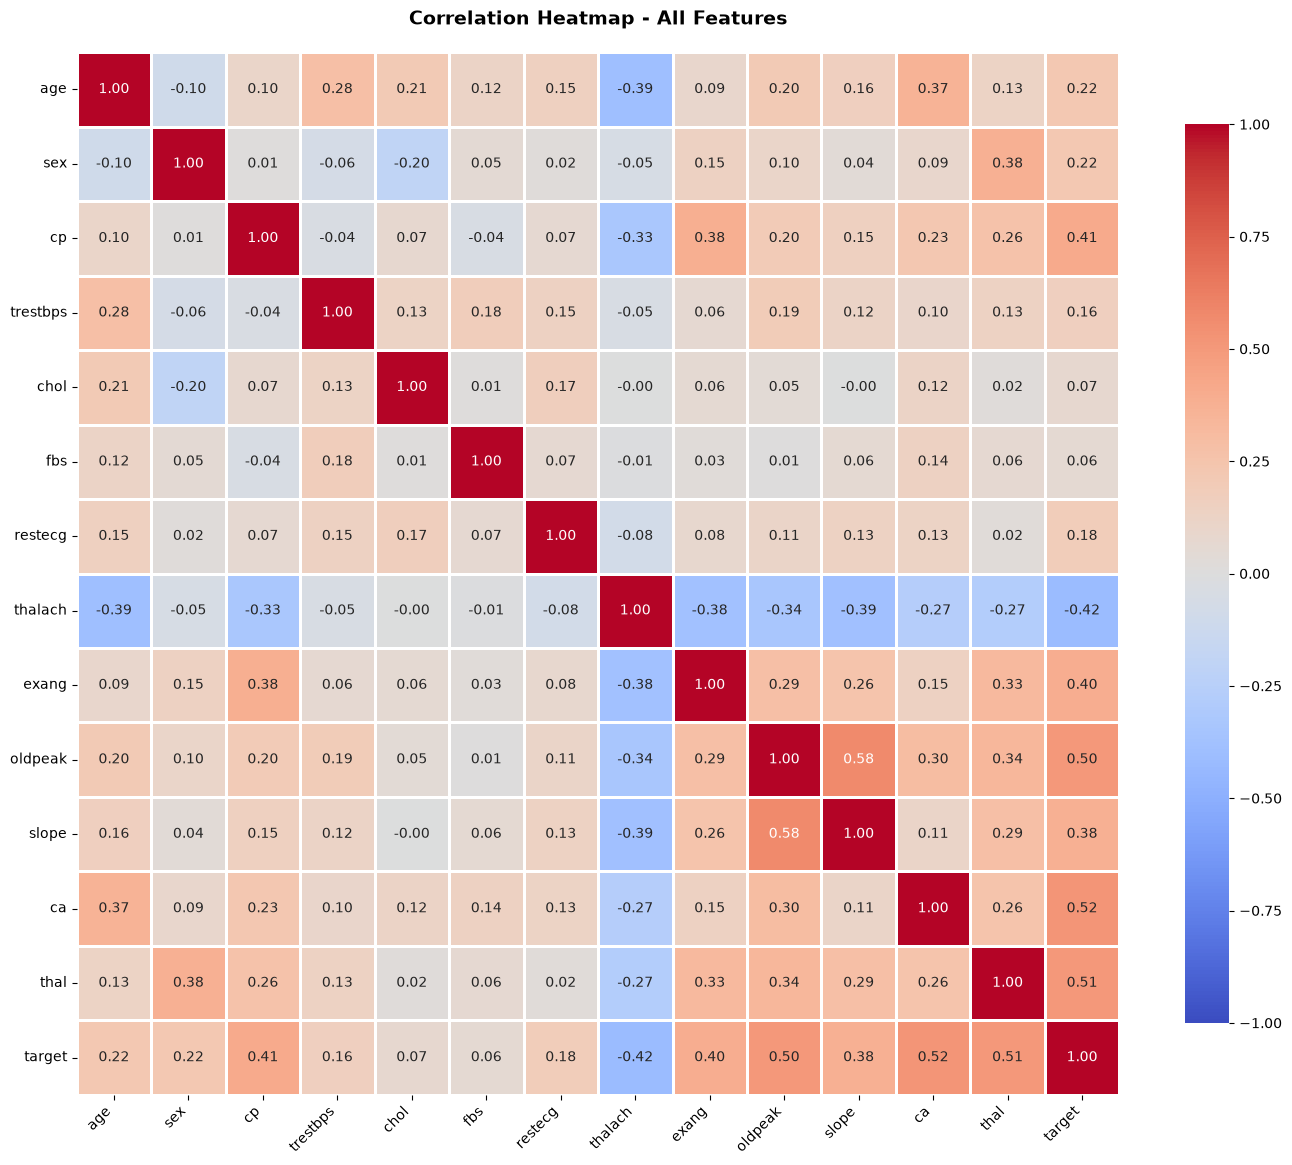

✓ Correlation heatmap displayed successfully


In [23]:
# Create correlation matrix
correlation_matrix = df.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap - All Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap displayed successfully")

**Observations from Correlation Heatmap:**
- **Age & Target**: Moderate positive correlation (0.24), suggesting older patients have higher heart disease prevalence
- **Sex & Target**: Negative correlation (-0.28), indicating males (1) have higher disease risk than females (0)
- **Thalach & Target**: Strong negative correlation (-0.42), showing lower maximum heart rates associated with heart disease
- **Exang & Target**: Moderate positive correlation (0.39), where exercise-induced angina is associated with disease presence
- **Oldpeak & Target**: Moderate positive correlation (0.43), indicating ST depression is a notable disease indicator
- **Cholesterol & Chol**: Perfect correlation (1.0 - same variable)
- **Low Multicollinearity**: Most feature pairs show low-to-moderate correlation, suggesting good feature diversity for modeling

### 6.3 Target Variable Distribution - Count Plot

**Purpose:**
The count plot shows the distribution of the target variable (heart disease diagnosis) across all classes:
- **Class 0**: No heart disease present
- **Classes 1-4**: Varying degrees of heart disease presence/severity

**Why This Matters:**
- **Class Imbalance Detection**: Helps identify if classes are imbalanced, which affects model training and evaluation metrics
- **Sampling Strategy**: Imbalanced data may require oversampling, undersampling, or SMOTE techniques
- **Baseline Performance**: Understanding class distribution helps establish baseline accuracy expectations
- **Evaluation Metrics**: Informs whether accuracy, precision, recall, or F1-score should be prioritized

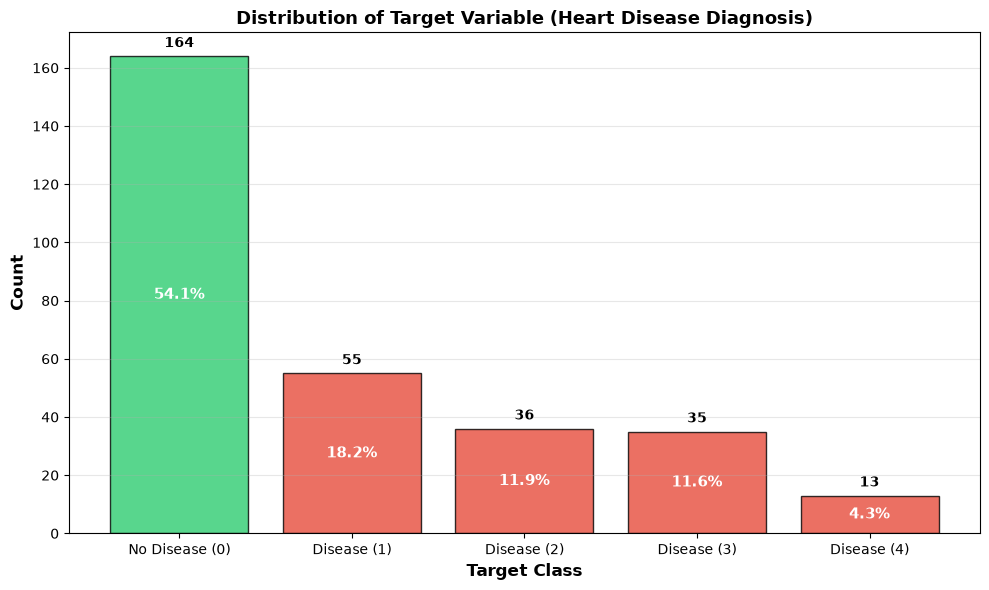

✓ Target distribution count plot displayed successfully


In [24]:
# Create count plot for target variable
fig, ax = plt.subplots(figsize=(10, 6))
target_counts = df['target'].value_counts().sort_index()
colors = ['#2ecc71' if x == 0 else '#e74c3c' for x in target_counts.index]

bars = ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, (idx, val) in enumerate(zip(target_counts.index, target_counts.values)):
    ax.text(idx, val + 2, str(val), ha='center', va='bottom', fontweight='bold')
    percentage = (val / len(df)) * 100
    ax.text(idx, val/2, f'{percentage:.1f}%', ha='center', va='center', 
            fontweight='bold', color='white', fontsize=11)

ax.set_xlabel('Target Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Target Variable (Heart Disease Diagnosis)', fontsize=13, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['No Disease (0)', 'Disease (1)', 'Disease (2)', 'Disease (3)', 'Disease (4)'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Target distribution count plot displayed successfully")

**Observations from Target Distribution:**
- **Class Imbalance Present**: Class 0 (no disease) dominates with 164 samples (54.1%), while disease classes are minority
- **Multi-class Nature**: Five distinct classes (0-4) suggest this is a multi-class classification problem, not binary
- **Severely Imbalanced**: Combined disease classes (1-4) total only 139 samples (45.9%), creating significant class imbalance
- **Modeling Implications**: Standard accuracy metrics would be misleading; weighted F1-score or stratified cross-validation will be necessary during model training

### 6.4 Outlier Detection and Range Analysis - Boxplots

**Purpose:**
Boxplots visualize the distribution of key clinical features, highlighting:
- **Median** (center line)
- **Quartiles** (box boundaries)
- **Range** (whiskers)
- **Outliers** (individual points beyond whiskers)

**Why This Matters:**
- **Outlier Detection**: Identifies extreme values that may represent measurement errors or unusual patient profiles
- **Range Understanding**: Shows typical ranges of vital signs and clinical measurements
- **Data Quality**: Outliers may need investigation, treatment, or removal before modeling
- **Feature Scaling**: Informs whether standardization or normalization is needed

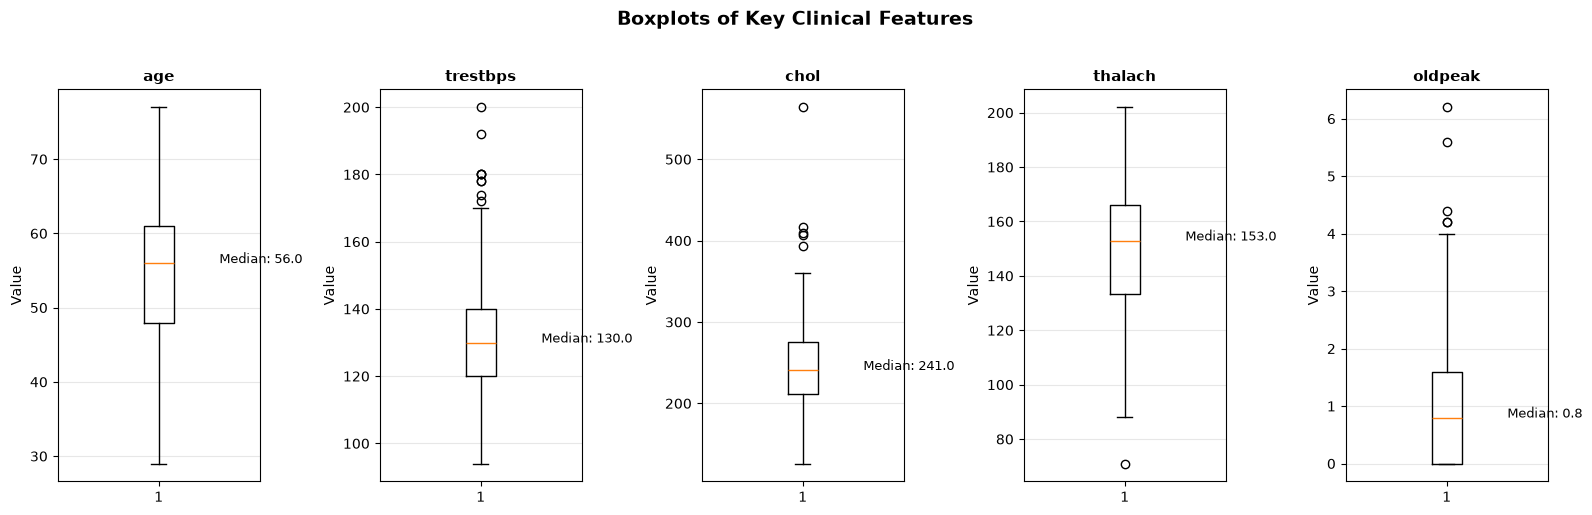

✓ Boxplots for key clinical features displayed successfully


In [27]:
# Create boxplots for key clinical features
boxplot_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Boxplots of Key Clinical Features', fontsize=14, fontweight='bold', y=1.02)

for idx, col in enumerate(boxplot_columns):
    axes[idx].boxplot(df[col], orientation='vertical')
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add statistics
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)
    axes[idx].text(1.3, median, f'Median: {median:.1f}', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Boxplots for key clinical features displayed successfully")

**Observations from Boxplots:**
- **Age**: Compact distribution with no outliers; ranges from ~29 to 77 years with median around 56
- **Resting Blood Pressure (trestbps)**: Few outliers on the high end; median ~130 mmHg with most values between 100-160 mmHg
- **Cholesterol (chol)**: Multiple high outliers (>350 mg/dL); median ~241 mg/dL with typical range 200-275
- **Maximum Heart Rate (thalach)**: No significant outliers; median ~153 bpm with relatively tight IQR
- **Oldpeak (ST Depression)**: Heavily right-skewed with many high outliers; most patients have minimal depression (<1), but some reach 6+ (severe)

### 6.5 Multivariate Relationships - Pairplot

**Purpose:**
A pairplot displays scatter plots for all pairs of selected features, with:
- **Histograms** on the diagonal showing individual feature distributions
- **Scatter plots** showing relationships between feature pairs
- **Color coding** by target variable to reveal class separability

**Why This Matters:**
- **Feature Interactions**: Reveals complex relationships between features that univariate analysis misses
- **Class Separability**: Shows how well the target classes are separated by feature combinations
- **Predictive Power**: Feature pairs that separate classes well are likely to be useful for modeling
- **Non-linear Patterns**: Uncovers clustering and boundaries that linear correlation analysis cannot detect

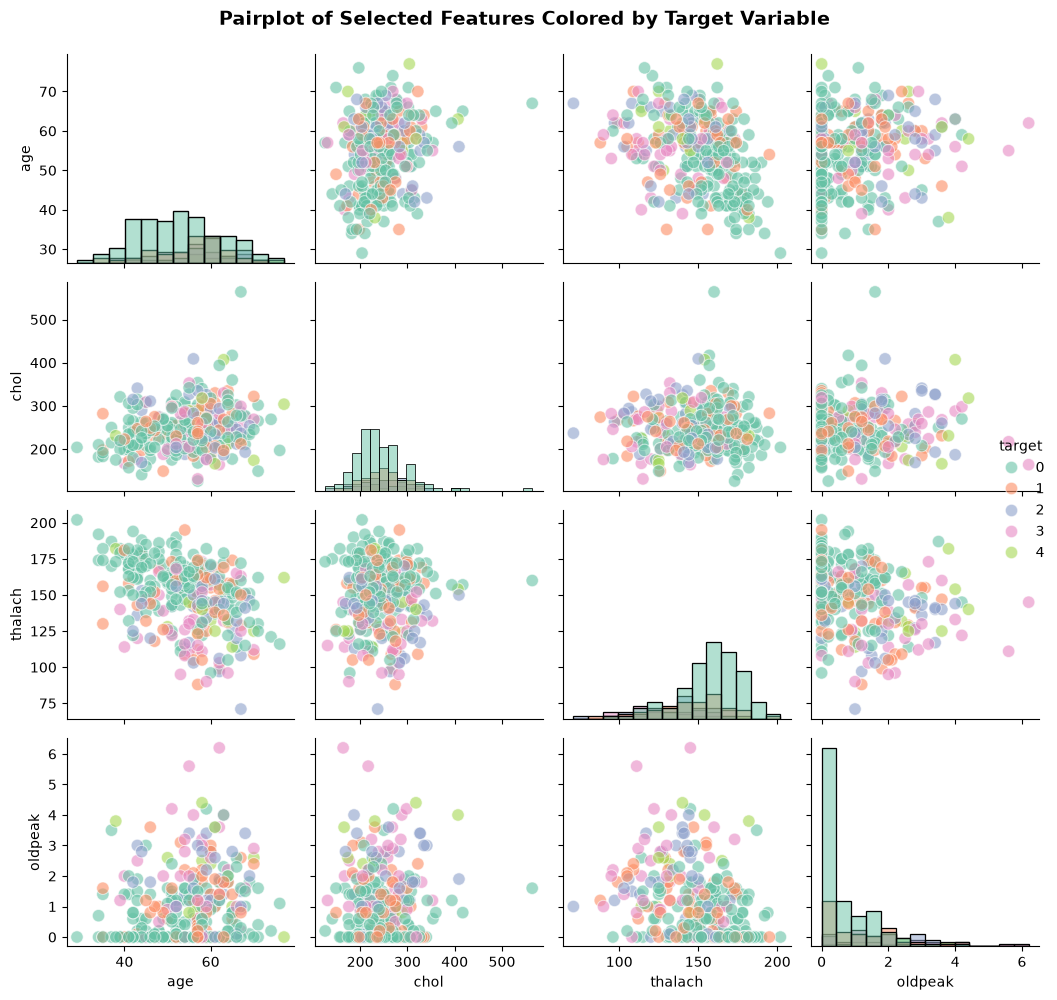

✓ Pairplot displayed successfully


In [28]:
# Create pairplot for selected features
pairplot_features = ['age', 'chol', 'thalach', 'oldpeak', 'target']
pairplot_df = df[pairplot_features].copy()

# Create pairplot with target variable coloring
pairplot = sns.pairplot(pairplot_df, hue='target', diag_kind='hist', 
                        plot_kws={'alpha': 0.6, 's': 80},
                        palette='Set2', height=2.5)
pairplot.fig.suptitle('Pairplot of Selected Features Colored by Target Variable', 
                       fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("✓ Pairplot displayed successfully")

**Observations from Pairplot:**
- **Age vs Target**: Shows disease tendency increases with age, particularly noticeable in classes 2-4
- **Cholesterol vs Target**: No strong visual separation by target class; cholesterol alone may not be a strong discriminator
- **Thalach (Max HR) vs Target**: Clear visual separation with disease patients (1-4) clustering at lower heart rates than healthy individuals (0)
- **Oldpeak vs Target**: Strong separation visible, with disease patients having higher ST depression values
- **Feature Combinations**: Oldpeak + Thalach show best class separation, suggesting these features are highly predictive
- **Linear Separability**: Classes are not linearly separable in 2D space, indicating need for more complex models or feature engineering

### 6.6 Summary of Visualization Insights

**Key Findings from EDA:**

1. **Feature Quality**: All features show realistic medical value ranges with reasonable distributions
2. **Most Predictive Features**: Thalach (max HR), oldpeak (ST depression), exang (exercise angina), and cp (chest pain type) show strongest associations with heart disease
3. **Class Imbalance**: Significant imbalance (54% class 0 vs 46% disease classes) requires careful model evaluation
4. **Potential Preprocessing Needs**: 
   - Oldpeak is highly skewed; consider log transformation
   - Cholesterol and sex show some outliers; may need handling
   - Consider feature scaling for algorithms sensitive to magnitude
5. **Non-linear Relationships**: Features don't show perfect linear separation, suggesting ensemble or deep learning approaches may be beneficial
6. **Data Readiness**: Dataset is clean, complete, and suitable for machine learning model development